# Volatility Smile Modelling and Option Pricing: Heston vs SABR with Calibration and Hedging

**Author:** Viriya Gunawan Lim  
**Last updated:** 2026-02-24  
**Repo:** `vol-smile-heston-sabr`  
**Notebook:** `Heston_vs_SABR_Calibration_Hedging.ipynb`

---

## 0. Executive Summary (fill after results)

**Objective.**  
Build a production-style pipeline to (i) construct implied-volatility smiles from option chains, (ii) calibrate **Heston** and **SABR** models, (iii) compare **fit** and **stability**, and (iv) evaluate **hedging performance** out-of-sample.

**Key questions.**
1. Which model fits the implied volatility surface better across strikes and maturities?
2. Which model is more stable under daily re-calibration (parameter drift, convergence)?
3. Which model yields better hedging PnL (delta / delta-vega) under realistic frictions?

**Deliverables.**
- Clean implied-vol surface construction + diagnostics
- Daily calibration results for Heston and SABR
- In-sample and rolling out-of-sample fit comparison
- Hedging backtest and risk metrics
- Summary figures + tables suitable for GitHub and CV bullets

---

## 1. Setup and Assumptions

### 1.1 Asset and market conventions
- **Underlying:** `<BTC / ETH / SPY / ...>`
- **Option style:** European (pricing and IV inversion assume European payoffs)
- **Pricing measure:** Risk-neutral (no-arbitrage)
- **Rates:** risk-free rate \( r(t) \) (constant or term structure)
- **Carry / dividend:** \( q(t) \) (0 for crypto; dividend yield / borrow for equities)
- **Forward:** \( F = S e^{(r-q)\tau} \)
- **Discount factor:** \( D = e^{-r\tau} \)

### 1.2 Data definitions
Each option quote is stored with the following fields:

- `date` : valuation date  
- `spot` : underlying spot price \( S \)  
- `expiry` : option expiry date  
- `tau` : time to maturity in years \( \tau \)  
- `strike` : strike \( K \)  
- `cp` : option type (`C` or `P`)  
- `bid`, `ask`, `mid` : bid/ask and mid price  
- `r`, `q` : risk-free and carry/dividend yields  
- computed:
  - `forward` \( F \)
  - `log_mny` \( \ln(K/F) \)
  - `iv_mid` : Black–Scholes implied vol from mid

### 1.3 Cleaning filters (initial defaults)
- **Maturity window:** \( \tau \in [\tau_{\min}, \tau_{\max}] \) (e.g., 7–180 days)
- **Moneyness window:** \( K/F \in [m_{\min}, m_{\max}] \) (e.g., 0.8–1.2)
- **Liquidity rules:** remove zero bids, extreme spreads, and obvious outliers
- **Pricing input:** use mid prices; track spreads for transaction-cost modelling

---

## 2. Models

### 2.1 SABR (smile model)
We use Hagan’s approximation to map \((\alpha, \beta, \rho, \nu)\) to an implied volatility function:
\[
\sigma_{\text{impl}}^{\text{SABR}}(K, \tau)
\]
- **Calibration target:** implied-vol RMSE across strikes (per maturity bucket)
- **Stability choice:** \(\beta\) will be `<fixed / estimated>` (default: fixed for robustness)

### 2.2 Heston (stochastic volatility model)
Heston dynamics under the risk-neutral measure:
\[
dS_t = (r-q)S_t\,dt + \sqrt{v_t}S_t\,dW_t^{(1)}, \quad
dv_t = \kappa(\theta - v_t)\,dt + \sigma\sqrt{v_t}\,dW_t^{(2)}, \quad
dW_t^{(1)} dW_t^{(2)} = \rho\,dt
\]
Parameters:
- \( v_0, \kappa, \theta, \sigma, \rho \)

Pricing via characteristic function (Fourier-based method), then convert to implied vols.

---

## 3. Calibration and Evaluation Protocol

### 3.1 Calibration objective (default)
Minimize implied-vol error (robust across strikes):
\[
\min_{\theta} \ \text{RMSE}\left(\sigma_{\text{model}}(K,\tau) - \sigma_{\text{mkt}}(K,\tau)\right)
\]
We use bounds and multi-start initialisation for numerical stability.

### 3.2 In-sample vs out-of-sample
- **In-sample:** calibrate and score on the same day
- **Rolling OOS:** calibrate on day \( t \), evaluate on day \( t+1 \) (matched strikes/maturities via interpolation rules)

### 3.3 Metrics
**Fit**
- IV RMSE (overall, by maturity bucket, by moneyness bucket)
- tail errors: max abs error, 95th percentile abs error

**Stability**
- parameter drift \(\Delta\theta_t\)
- convergence rate and boundary hits

**Hedging**
- delta-hedge PnL
- delta-vega-hedge PnL
- Sharpe, max drawdown, downside tail (5% quantile), turnover

---

## 4. Transaction Costs and Frictions (for hedging)
- **Underlying slippage:** half-spread or bps cost per trade
- **Options slippage:** half-spread from bid/ask
- **Re-hedge frequency:** daily (baseline)

---

## 5. Roadmap (Notebook Sections)
1. Imports + configuration  
2. Data ingestion (real/synthetic)  
3. Black–Scholes pricer + implied vol + greeks  
4. Smile construction + diagnostics  
5. SABR implementation + calibration  
6. Heston implementation + calibration  
7. Fit & stability comparison (IS + rolling OOS)  
8. Hedging backtest (delta / delta-vega)  
9. Results summary + conclusions + future work

---

## 6. Notes / TODO
- [ ] Confirm data source and coverage (dates, underlying, maturities)
- [ ] Lock calibration scheme (bucketed vs global)
- [ ] Choose hedged instrument set (ATM straddle baseline)
- [ ] Define interpolation rules for OOS evaluation

## 1. Imports and Global Configuration
This section sets up dependencies, plotting defaults, and project-wide parameters (data filters, calibration settings, and hedging assumptions).  
**Rule:** all downstream code reads from a single `CFG` dictionary to avoid hard-coded values.

In [1]:
# ==============================
# 1) Imports and Global Config
# ==============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, Tuple, Optional, List

from scipy import optimize, stats
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

# ------------------------------
# Global configuration (edit here only)
# ------------------------------
CFG: Dict = {
    # --- Asset / data ---
    "underlying": "BTC",                 # e.g., "BTC", "ETH", "SPY"
    "data_source": "deribit_or_csv",     # "deribit" | "csv" | "synthetic"
    "timezone": "UTC",

    # --- Rates / carry ---
    "r": 0.03,                           # flat rate (annualized); replace with curve if available
    "q": 0.00,                           # carry/dividend yield (0 for crypto baseline)

    # --- Filters ---
    "min_days": 7,                       # maturity lower bound (days)
    "max_days": 180,                     # maturity upper bound (days)
    "mny_min": 0.80,                     # strike/forward lower bound
    "mny_max": 1.20,                     # strike/forward upper bound
    "min_mid": 1e-8,                     # ignore non-positive mids
    "max_spread_frac": 0.25,             # drop if (ask-bid)/mid > this
    "min_quotes_per_maturity": 10,       # minimum strikes per maturity bucket to fit

    # --- Bucketing (for SABR calibration and reporting) ---
    "maturity_buckets_days": [(7, 30), (31, 90), (91, 180)],  # adjust to your data coverage
    "moneyness_buckets": [(0.80, 0.90), (0.90, 1.00), (1.00, 1.10), (1.10, 1.20)],

    # --- SABR calibration ---
    "sabr_beta_mode": "fixed",           # "fixed" or "grid" or "free"
    "sabr_beta_fixed": 1.0,              # 1.0 = lognormal SABR (common), 0.5 = CEV-like
    "sabr_beta_grid": [0.0, 0.5, 1.0],   # used if sabr_beta_mode == "grid"
    "sabr_bounds": {                     # (low, high)
        "alpha": (1e-6, 5.0),
        "rho": (-0.999, 0.999),
        "nu": (1e-6, 5.0),
    },

    # --- Heston calibration ---
    "heston_bounds": {
        "v0": (1e-6, 2.0),
        "kappa": (1e-4, 50.0),
        "theta": (1e-6, 2.0),
        "sigma": (1e-6, 10.0),
        "rho": (-0.999, 0.999),
    },
    "heston_penalty_feller": True,       # penalize 2*kappa*theta < sigma^2
    "heston_feller_weight": 10.0,        # penalty weight (tune if needed)

    # --- Optimizer / robustness ---
    "optimizer": "L-BFGS-B",
    "n_multistart": 5,                   # multi-start attempts per calibration
    "maxiter": 300,

    # --- Hedging assumptions ---
    "hedge_freq": "1D",                  # daily
    "tc_underlying_bps": 2.0,            # underlying transaction cost in bps per trade (simple model)
    "tc_option_half_spread": True,       # charge half-spread on option trades

    # --- Plotting ---
    "figsize": (10, 5),
}

print("CFG loaded. Underlying =", CFG["underlying"])

CFG loaded. Underlying = BTC


In [2]:
# ------------------------------
# Helper: maturity buckets (days -> year fractions)
# ------------------------------
def days_to_tau(days: float) -> float:
    return float(days) / 365.0

def bucket_by_days(days: float, buckets: List[Tuple[int, int]]) -> Optional[str]:
    """
    Return a bucket label like '7-30D' given days to expiry.
    """
    for lo, hi in buckets:
        if lo <= days <= hi:
            return f"{lo}-{hi}D"
    return None

# Quick sanity check
for d in [10, 45, 120, 250]:
    print(d, "->", bucket_by_days(d, CFG["maturity_buckets_days"]))

10 -> 7-30D
45 -> 31-90D
120 -> 91-180D
250 -> None


## 2. Data Ingestion — Synthetic Option Surface

We generate a realistic synthetic option chain to:

- test calibration pipelines
- validate smile construction
- debug pricing engines
- enable hedging experiments

The synthetic market is generated using Black–Scholes with a volatility smile:

\[
\sigma(K, \tau) = \sigma_{ATM} + skew \cdot \log(K/F) + curvature \cdot \log(K/F)^2
\]

We also simulate bid–ask spreads to mimic market frictions.

Later this section can be replaced with real option chain data.

In [5]:
# ==============================
# Step 2) Data Ingestion — Synthetic Option Surface (REVISED)
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Reuse CFG["r"], CFG["q"], CFG["figsize"] from Step 1 ---

def forward_price(S: float, tau: float, r: float, q: float) -> float:
    return float(S) * np.exp((r - q) * float(tau))

def discount_factor(tau: float, r: float) -> float:
    return np.exp(-float(r) * float(tau))

def bs_price_call(S: float, K: float, tau: float, r: float, q: float, sigma: float) -> float:
    tau = float(tau)
    sigma = float(sigma)
    if tau <= 0:
        return max(float(S) - float(K), 0.0)
    if sigma <= 0:
        # deterministic forward payoff discounted (approx)
        F = forward_price(S, tau, r, q)
        D = discount_factor(tau, r)
        return max(D * (F - K), 0.0)

    F = forward_price(S, tau, r, q)
    D = discount_factor(tau, r)

    vol_sqrt = sigma * np.sqrt(tau)
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * tau) / vol_sqrt
    d2 = d1 - vol_sqrt
    return float(D * (F * stats.norm.cdf(d1) - K * stats.norm.cdf(d2)))

def bs_price_put(S: float, K: float, tau: float, r: float, q: float, sigma: float) -> float:
    # put-call parity in forward form
    call = bs_price_call(S, K, tau, r, q, sigma)
    F = forward_price(S, tau, r, q)
    D = discount_factor(tau, r)
    return float(call - D * (F - K))

def smile_vol_quadratic(K: float, F: float, tau: float,
                        sigma_atm: float = 0.60,
                        skew: float = -0.30,
                        curvature: float = 0.40) -> float:
    """
    Simple synthetic smile:
      sigma = sigma_atm + skew * log(K/F) + curvature * log(K/F)^2
    """
    x = np.log(float(K) / float(F))
    sig = sigma_atm + skew * x + curvature * (x ** 2)
    return float(max(0.05, sig))  # floor to avoid degeneracy

def make_bid_ask(price: float, spread_frac: float = 0.02, spread_floor: float = 1e-4):
    """
    Enforce market microstructure constraints:
      - bid >= 0
      - ask >= bid
      - mid between bid and ask (we keep 'mid' as model price)
    """
    price = float(price)
    spread = max(spread_floor, spread_frac * abs(price))
    bid = max(0.0, price - 0.5 * spread)
    ask = max(bid, price + 0.5 * spread)
    return bid, ask

def generate_synthetic_chain(
    n_days: int = 60,
    start_date: str = "2025-01-01",
    S0: float = 50000.0,
    spot_daily_vol: float = 0.01,              # random spot perturbation
    maturities_days=(14, 30, 60, 90),
    strikes_mny=(0.70, 1.30),
    n_strikes: int = 25,
    spread_frac: float = 0.02
) -> pd.DataFrame:
    rows = []
    dates = pd.date_range(start_date, periods=n_days, freq="D")

    mny_grid = np.linspace(strikes_mny[0], strikes_mny[1], n_strikes)

    r = float(CFG["r"])
    q = float(CFG["q"])

    for date in dates:
        # Mild random walk around S0 (simple; good enough for synthetic)
        S = float(S0) * np.exp(spot_daily_vol * np.random.randn())

        for d in maturities_days:
            tau = float(d) / 365.0
            F = forward_price(S, tau, r, q)

            for mny in mny_grid:
                K = float(mny) * F
                sigma = smile_vol_quadratic(K, F, tau)

                call_mid = bs_price_call(S, K, tau, r, q, sigma)
                put_mid  = bs_price_put(S, K, tau, r, q, sigma)

                call_bid, call_ask = make_bid_ask(call_mid, spread_frac=spread_frac)
                put_bid,  put_ask  = make_bid_ask(put_mid,  spread_frac=spread_frac)

                rows.append({
                    "date": date,
                    "spot": S,
                    "tau": tau,
                    "days": int(d),
                    "strike": K,
                    "cp": "C",
                    "mid": call_mid,
                    "bid": call_bid,
                    "ask": call_ask,
                    "r": r,
                    "q": q,
                })

                rows.append({
                    "date": date,
                    "spot": S,
                    "tau": tau,
                    "days": int(d),
                    "strike": K,
                    "cp": "P",
                    "mid": put_mid,
                    "bid": put_bid,
                    "ask": put_ask,
                    "r": r,
                    "q": q,
                })

    df = pd.DataFrame(rows)

    # Sanity enforcement
    df["mid"] = df["mid"].clip(lower=0.0)
    df["bid"] = df["bid"].clip(lower=0.0)
    df["ask"] = np.maximum(df["ask"].values, df["bid"].values)

    return df

# ---- Generate synthetic dataset ----
df_chain = generate_synthetic_chain()

# ---- Quick sanity checks ----
print("Synthetic chain shape:", df_chain.shape)
print("Unique dates:", df_chain["date"].nunique())
print("Maturities (days):", sorted(df_chain["days"].unique()))

print("Negative bids:", int((df_chain["bid"] < 0).sum()))
print("Negative mids:", int((df_chain["mid"] < 0).sum()))
print("Bid > Ask violations:", int((df_chain["bid"] > df_chain["ask"]).sum()))
print("Mid outside [bid,ask]:", int(((df_chain["mid"] < df_chain["bid"]) | (df_chain["mid"] > df_chain["ask"])).sum()))

df_chain.head()

Synthetic chain shape: (12000, 11)
Unique dates: 60
Maturities (days): [np.int64(14), np.int64(30), np.int64(60), np.int64(90)]
Negative bids: 0
Negative mids: 0
Bid > Ask violations: 0
Mid outside [bid,ask]: 0


,date,spot,tau,days,strike,cp,mid,bid,ask,r,q
0,2025-01-01,49760.985985,0.038356,14,34872.794711,C,14944.919221,14795.470029,15094.368414,0.03,0.0
1,2025-01-01,49760.985985,0.038356,14,34872.794711,P,16.623426,16.457192,16.789660,0.03,0.0
2,2025-01-01,49760.985985,0.038356,14,36118.251665,C,13712.038323,13574.917940,13849.158706,0.03,0.0
3,2025-01-01,49760.985985,0.038356,14,36118.251665,P,27.767177,27.489505,28.044849,0.03,0.0
4,2025-01-01,49760.985985,0.038356,14,37363.708619,C,12486.210528,12361.348423,12611.072634,0.03,0.0


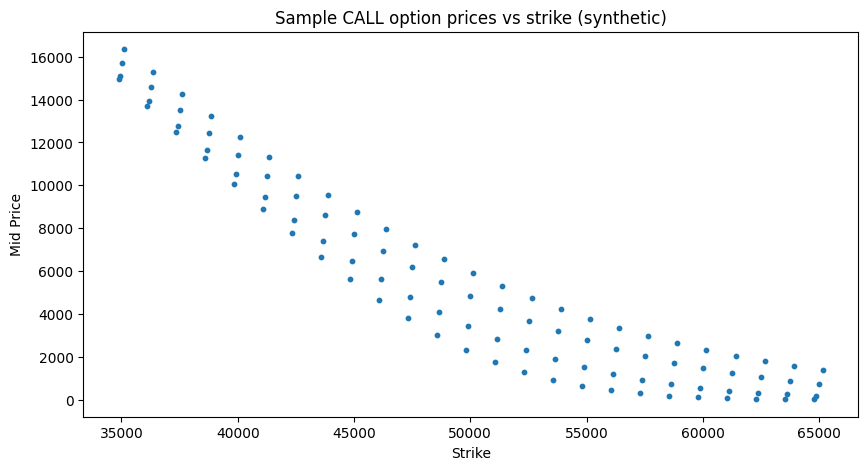

In [6]:
# ---- Plot sample: option prices vs strike (one day) ----
plt.figure(figsize=CFG["figsize"])
sample = df_chain[df_chain["date"] == df_chain["date"].iloc[0]]

# Plot calls only for readability (puts similar)
calls = sample[sample["cp"] == "C"]
plt.scatter(calls["strike"], calls["mid"], s=10)

plt.title("Sample CALL option prices vs strike (synthetic)")
plt.xlabel("Strike")
plt.ylabel("Mid Price")
plt.show()

## 3. Black–Scholes Engine: Pricing, Implied Volatility, and Greeks

We implement:
- Black–Scholes pricing (call/put) under carry \(q\)
- Robust implied volatility inversion (Brent root-finding)
- Greeks (delta, vega) for hedging and diagnostics

These functions are used for:
1) computing market implied vols from mid prices  
2) converting model prices back into implied vols for fair comparison  
3) hedging simulations (delta / vega)

In [7]:
# ==============================
# 3) Black–Scholes + IV + Greeks
# ==============================

from math import log, sqrt, exp
from scipy.stats import norm
from scipy.optimize import brentq

def _check_inputs(S, K, tau, sigma):
    if S <= 0 or K <= 0 or tau <= 0 or sigma <= 0:
        return False
    return True

def bs_price(S: float, K: float, tau: float, r: float, q: float, sigma: float, cp: str) -> float:
    """
    Black–Scholes price with continuous carry q using forward formulation.
    cp: 'C' or 'P'
    """
    S, K, tau, r, q, sigma = map(float, (S, K, tau, r, q, sigma))
    cp = cp.upper()

    if tau <= 0:
        return max(S - K, 0.0) if cp == "C" else max(K - S, 0.0)

    if sigma <= 0:
        # Degenerate (rare): discount intrinsic of forward payoff
        F = S * exp((r - q) * tau)
        D = exp(-r * tau)
        call = max(D * (F - K), 0.0)
        return call if cp == "C" else call - D * (F - K)

    F = S * exp((r - q) * tau)
    D = exp(-r * tau)

    vol_sqrt = sigma * sqrt(tau)
    d1 = (log(F / K) + 0.5 * sigma * sigma * tau) / vol_sqrt
    d2 = d1 - vol_sqrt

    call = D * (F * norm.cdf(d1) - K * norm.cdf(d2))
    if cp == "C":
        return float(call)
    else:
        # put-call parity in forward form
        return float(call - D * (F - K))

def bs_delta(S: float, K: float, tau: float, r: float, q: float, sigma: float, cp: str) -> float:
    """
    Delta w.r.t spot S under BS with carry q.
    """
    S, K, tau, r, q, sigma = map(float, (S, K, tau, r, q, sigma))
    cp = cp.upper()

    if not _check_inputs(S, K, tau, sigma):
        # fallback to intrinsic delta at expiry
        if tau <= 0:
            if cp == "C":
                return 1.0 if S > K else 0.0
            else:
                return -1.0 if S < K else 0.0
        return np.nan

    F = S * exp((r - q) * tau)
    vol_sqrt = sigma * sqrt(tau)
    d1 = (log(F / K) + 0.5 * sigma * sigma * tau) / vol_sqrt

    # delta for forward-form BS: e^{-q tau} N(d1) for calls
    disc_q = exp(-q * tau)
    if cp == "C":
        return float(disc_q * norm.cdf(d1))
    else:
        return float(disc_q * (norm.cdf(d1) - 1.0))

def bs_vega(S: float, K: float, tau: float, r: float, q: float, sigma: float) -> float:
    """
    Vega (per 1.00 vol, not per 1%) under BS with carry q.
    """
    S, K, tau, r, q, sigma = map(float, (S, K, tau, r, q, sigma))

    if not _check_inputs(S, K, tau, sigma):
        return np.nan

    F = S * exp((r - q) * tau)
    D = exp(-r * tau)
    vol_sqrt = sigma * sqrt(tau)
    d1 = (log(F / K) + 0.5 * sigma * sigma * tau) / vol_sqrt

    # Forward-form vega: D * F * n(d1) * sqrt(tau)
    return float(D * F * norm.pdf(d1) * sqrt(tau))

def implied_vol(price: float, S: float, K: float, tau: float, r: float, q: float, cp: str,
                vol_low: float = 1e-6, vol_high: float = 5.0) -> float:
    """
    Robust implied vol via bracketing + Brent.
    Returns np.nan if inversion fails.
    """
    price = float(price)
    if price <= 0 or S <= 0 or K <= 0 or tau <= 0:
        return np.nan

    cp = cp.upper()

    # No-arbitrage bounds (loose, but useful)
    F = S * np.exp((r - q) * tau)
    D = np.exp(-r * tau)

    if cp == "C":
        lower = max(0.0, D * (F - K))
        upper = D * F  # loose upper bound
    else:
        lower = max(0.0, D * (K - F))
        upper = D * K  # loose upper bound

    if not (lower - 1e-8 <= price <= upper + 1e-8):
        return np.nan

    def f(sig):
        return bs_price(S, K, tau, r, q, sig, cp) - price

    try:
        f_low = f(vol_low)
        f_high = f(vol_high)
        if np.sign(f_low) == np.sign(f_high):
            # try expanding bracket
            vol_high2 = 10.0
            f_high2 = f(vol_high2)
            if np.sign(f_low) == np.sign(f_high2):
                return np.nan
            return float(brentq(f, vol_low, vol_high2, maxiter=200))
        return float(brentq(f, vol_low, vol_high, maxiter=200))
    except Exception:
        return np.nan

In [8]:
# Compute forward + log-moneyness + market IV (from mid)
df = df_chain.copy()

df["forward"] = df["spot"] * np.exp((df["r"] - df["q"]) * df["tau"])
df["log_mny"] = np.log(df["strike"] / df["forward"])

df["iv_mid"] = df.apply(
    lambda x: implied_vol(
        x["mid"], x["spot"], x["strike"], x["tau"], x["r"], x["q"], x["cp"]
    ),
    axis=1
)

print("IV computed. NaN IV count:", int(df["iv_mid"].isna().sum()))
df.head()

IV computed. NaN IV count: 0


,date,spot,tau,days,strike,cp,mid,bid,ask,r,q,forward,log_mny,iv_mid
0,2025-01-01,49760.985985,0.038356,14,34872.794711,C,14944.919221,14795.470029,15094.368414,0.03,0.0,49818.278158,-0.356675,0.757889
1,2025-01-01,49760.985985,0.038356,14,34872.794711,P,16.623426,16.457192,16.789660,0.03,0.0,49818.278158,-0.356675,0.757889
2,2025-01-01,49760.985985,0.038356,14,36118.251665,C,13712.038323,13574.917940,13849.158706,0.03,0.0,49818.278158,-0.321584,0.737841
3,2025-01-01,49760.985985,0.038356,14,36118.251665,P,27.767177,27.489505,28.044849,0.03,0.0,49818.278158,-0.321584,0.737841
4,2025-01-01,49760.985985,0.038356,14,37363.708619,C,12486.210528,12361.348423,12611.072634,0.03,0.0,49818.278158,-0.287682,0.719409


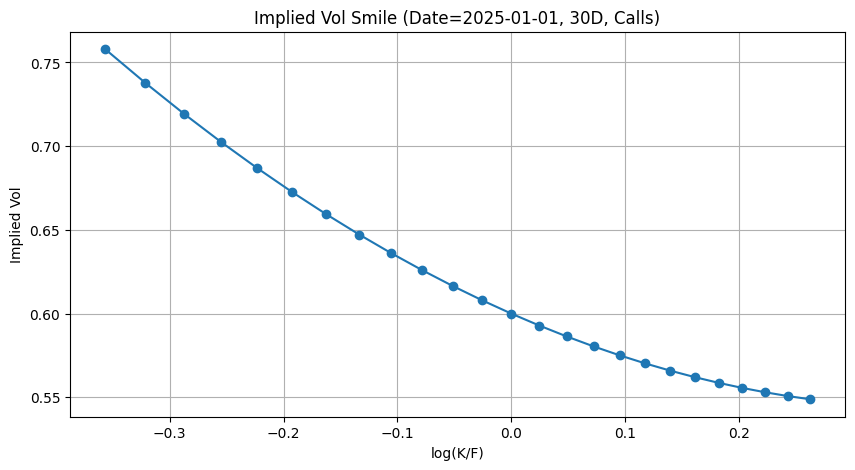

In [9]:
#plot a smile 
plt.figure(figsize=CFG["figsize"])
d0 = df["date"].min()
sub = df[(df["date"] == d0) & (df["days"] == 30) & (df["cp"] == "C")].sort_values("log_mny")
plt.plot(sub["log_mny"], sub["iv_mid"], marker="o", linestyle="-")
plt.title(f"Implied Vol Smile (Date={d0.date()}, 30D, Calls)")
plt.xlabel("log(K/F)")
plt.ylabel("Implied Vol")
plt.grid(True)
plt.show()

## 4. Cleaning, Bucketing, and Smile Diagnostics

We prepare the implied-vol dataset for model calibration by:

1) applying liquidity and quality filters  
2) creating maturity buckets (e.g., 7–30D, 31–90D, 91–180D)  
3) creating moneyness buckets (e.g., 0.8–0.9, ..., 1.1–1.2)  
4) generating diagnostics: coverage, spreads, smile consistency

Output: a clean dataset `df_iv` ready for SABR/Heston calibration.

In [10]:
# ==============================
# 4) Cleaning + Bucketing
# ==============================

df_iv = df.copy()

# Spread fraction (use mid; safe because mid>0 by construction)
df_iv["spread"] = df_iv["ask"] - df_iv["bid"]
df_iv["spread_frac"] = df_iv["spread"] / df_iv["mid"].replace(0, np.nan)

# Basic filters
mask = (
    (df_iv["days"] >= CFG["min_days"]) &
    (df_iv["days"] <= CFG["max_days"]) &
    (df_iv["mid"] >= CFG["min_mid"]) &
    (df_iv["spread_frac"] <= CFG["max_spread_frac"]) &
    (df_iv["iv_mid"].notna())
)
df_iv = df_iv.loc[mask].copy()

# Moneyness ratio K/F
df_iv["mny"] = df_iv["strike"] / df_iv["forward"]

# Moneyness window filter
df_iv = df_iv[(df_iv["mny"] >= CFG["mny_min"]) & (df_iv["mny"] <= CFG["mny_max"])].copy()

# Maturity bucket label
df_iv["mat_bucket"] = df_iv["days"].apply(lambda d: bucket_by_days(d, CFG["maturity_buckets_days"]))

# Drop those outside bucket scheme (shouldn't happen given your maturities, but keep clean)
df_iv = df_iv[df_iv["mat_bucket"].notna()].copy()

# Moneyness bucket label
def bucket_mny(m, buckets):
    for lo, hi in buckets:
        if lo <= m <= hi:
            return f"{lo:.2f}-{hi:.2f}"
    return None

df_iv["mny_bucket"] = df_iv["mny"].apply(lambda m: bucket_mny(m, CFG["moneyness_buckets"]))
df_iv = df_iv[df_iv["mny_bucket"].notna()].copy()

print("After cleaning shape:", df_iv.shape)
print("Unique dates:", df_iv["date"].nunique())
print("Maturity buckets:", sorted(df_iv["mat_bucket"].unique()))
print("Moneyness buckets:", sorted(df_iv["mny_bucket"].unique()))

After cleaning shape: (7300, 19)
Unique dates: 60
Maturity buckets: ['31-90D', '7-30D']
Moneyness buckets: ['0.80-0.90', '0.90-1.00', '1.00-1.10', '1.10-1.20']


In [11]:
# Coverage: number of quotes per date per maturity bucket
coverage = (
    df_iv.groupby(["date", "mat_bucket"])
         .size()
         .unstack(fill_value=0)
)

display(coverage.head())

print("Min quotes per bucket (over time):")
print(coverage.min())

print("Any bucket below min_quotes_per_maturity?",
      (coverage < CFG["min_quotes_per_maturity"]).any().any())

mat_bucket,31-90D,7-30D
date,,
2025-01-01,62,62
2025-01-02,60,62
2025-01-03,60,62
2025-01-04,60,62
2025-01-05,60,60


Min quotes per bucket (over time):
mat_bucket
31-90D    60
7-30D     60
dtype: int64
Any bucket below min_quotes_per_maturity? False


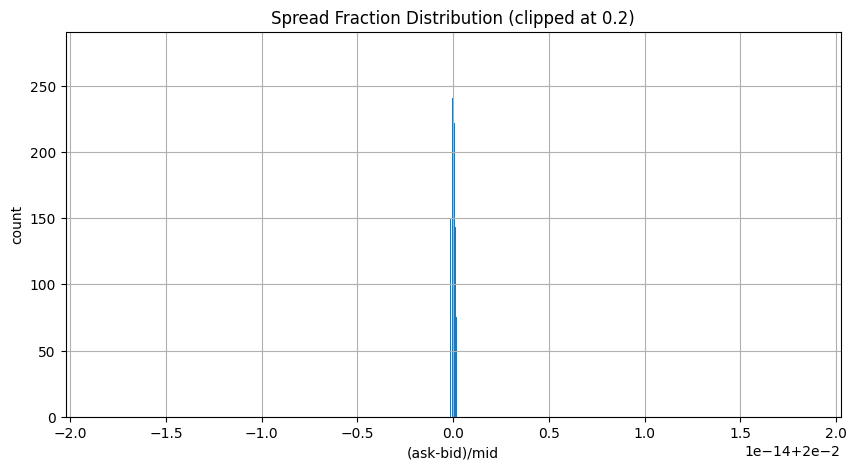

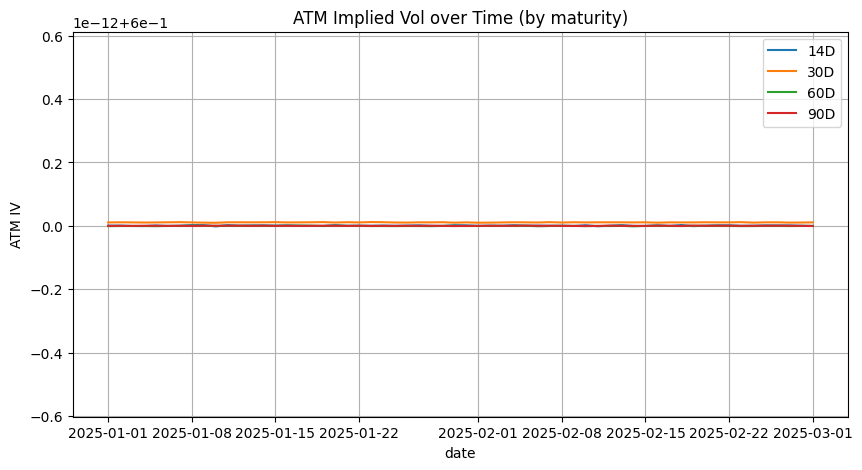

In [12]:
# 1) Spread distribution
plt.figure(figsize=CFG["figsize"])
plt.hist(df_iv["spread_frac"].clip(upper=0.2), bins=50)
plt.title("Spread Fraction Distribution (clipped at 0.2)")
plt.xlabel("(ask-bid)/mid")
plt.ylabel("count")
plt.grid(True)
plt.show()

# 2) ATM-ish term structure: take nearest mny to 1.0 per (date, days)
tmp = df_iv.copy()
tmp["atm_dist"] = (tmp["mny"] - 1.0).abs()
atm = tmp.sort_values("atm_dist").groupby(["date", "days"], as_index=False).first()

plt.figure(figsize=CFG["figsize"])
for d in sorted(atm["days"].unique()):
    plt.plot(atm[atm["days"] == d]["date"], atm[atm["days"] == d]["iv_mid"], label=f"{d}D")
plt.title("ATM Implied Vol over Time (by maturity)")
plt.xlabel("date")
plt.ylabel("ATM IV")
plt.grid(True)
plt.legend()
plt.show()

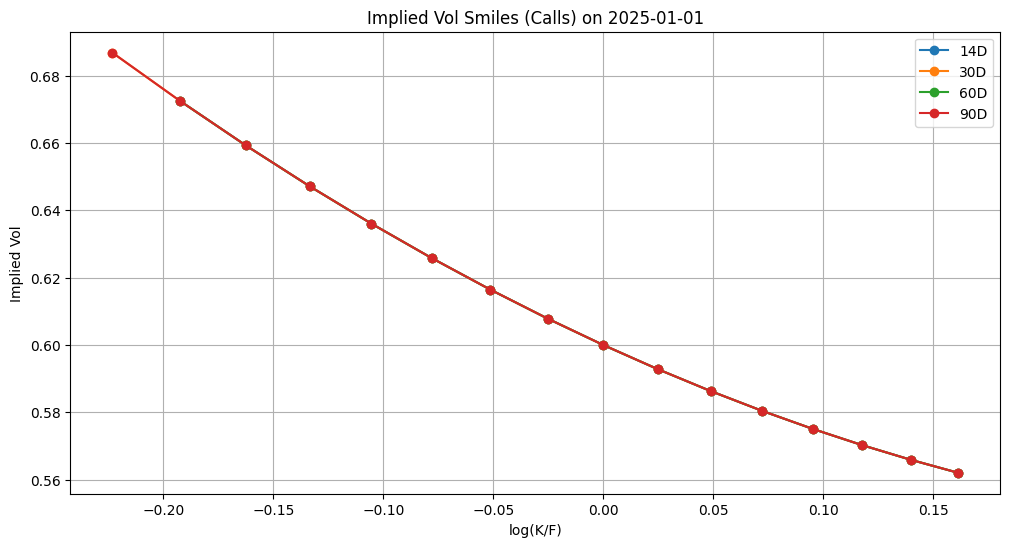

In [13]:
# Smile snapshot grid: choose one date and plot IV vs log_mny for each maturity
d0 = df_iv["date"].min()
plt.figure(figsize=(12, 6))

for days in sorted(df_iv["days"].unique()):
    sub = df_iv[(df_iv["date"] == d0) & (df_iv["days"] == days) & (df_iv["cp"] == "C")].sort_values("log_mny")
    plt.plot(sub["log_mny"], sub["iv_mid"], marker="o", linestyle="-", label=f"{days}D")

plt.title(f"Implied Vol Smiles (Calls) on {d0.date()}")
plt.xlabel("log(K/F)")
plt.ylabel("Implied Vol")
plt.grid(True)
plt.legend()
plt.show()

## 5. SABR Model (Hagan Approximation) and Calibration

We calibrate SABR to market implied vols (from mid prices).

- Model: lognormal SABR (Hagan implied vol approximation)
- Parameters: (alpha, beta, rho, nu)
- Default: beta fixed (stable). We fit (alpha, rho, nu) per (date, maturity).

Objective:
\[
\min_{\theta} \text{RMSE}(\sigma_{\text{SABR}}(K,\tau) - \sigma_{\text{mkt}}(K,\tau))
\]

Outputs:
- daily parameters per maturity
- in-sample fit RMSE
- fitted vs market smile plots

In [19]:
def sabr_iv_hagan_lognormal(F, K, tau, alpha, beta, rho, nu):
    F = float(F); K = float(K); tau = float(tau)
    alpha = float(alpha); beta = float(beta); rho = float(rho); nu = float(nu)

    if F <= 0 or K <= 0 or tau <= 0:
        return np.nan
    if alpha <= 0 or nu <= 0 or not (-0.999 < rho < 0.999) or not (0.0 <= beta <= 1.0):
        return np.nan

    eps = 1e-12
    logFK = np.log(F / K)

    # ATM handling
    if abs(logFK) < 1e-8:
        FK_beta = F ** (1 - beta)
        term1 = alpha / max(eps, FK_beta)
        A = ((1 - beta)**2 / 24) * (alpha**2 / max(eps, F**(2 - 2*beta)))
        B = (rho * beta * nu * alpha) / (4 * max(eps, F**(1 - beta)))
        C = (2 - 3*rho**2) * (nu**2 / 24)
        iv = term1 * (1 + (A + B + C) * tau)
        return float(max(1e-6, iv))

    FK = F * K
    FK_beta = FK ** ((1 - beta) / 2)

    z = (nu / alpha) * FK_beta * logFK

    # Stability: if z is too large, approximation becomes unreliable
    if abs(z) > 50:
        return np.nan

    sqrt_term = np.sqrt(max(eps, 1 - 2*rho*z + z*z))
    denom = (1 - rho)
    if denom <= 0:
        return np.nan

    xz = np.log((sqrt_term + z - rho) / denom)
    if abs(xz) < 1e-12:
        return np.nan

    denom2 = FK_beta * (1 + ((1 - beta)**2 / 24) * (logFK**2) + ((1 - beta)**4 / 1920) * (logFK**4))
    base = (alpha / max(eps, denom2)) * (z / xz)

    A = ((1 - beta)**2 / 24) * (alpha**2 / max(eps, FK**(1 - beta)))
    B = (rho * beta * nu * alpha) / (4 * max(eps, FK_beta))
    C = (2 - 3*rho**2) * (nu**2 / 24)

    iv = base * (1 + (A + B + C) * tau)
    return float(max(1e-6, iv))

In [20]:
# ==============================
# SABR calibration utilities
# ==============================

def sabr_rmse(params, F, K, tau, iv_mkt, beta):
    alpha, rho, nu = params

    iv_fit = np.array([
        sabr_iv_hagan_lognormal(F[i], K[i], tau[i], alpha, beta, rho, nu)
        for i in range(len(K))
    ])

    # If any NaN -> huge penalty
    if np.any(~np.isfinite(iv_fit)):
        return 1e6

    rmse = float(np.sqrt(np.mean((iv_fit - iv_mkt) ** 2)))

    # Penalize weird values (too high IV)
    penalty = 0.0
    penalty += 1000.0 * float(np.mean(iv_fit > 3.0))   # SABR IV > 300% is suspicious here
    penalty += 1000.0 * float(np.mean(iv_fit < 0.01))  # too low
    return rmse + penalty

def calibrate_sabr_one_slice(df_slice, beta_fixed=1.0, n_multistart=5):
    """
    Calibrate SABR to one (date, days) slice.
    Uses multi-start L-BFGS-B on (alpha, rho, nu).
    """
    F = df_slice["forward"].values
    K = df_slice["strike"].values
    tau = df_slice["tau"].values
    iv_mkt = df_slice["iv_mid"].values

    bounds = [CFG["sabr_bounds"]["alpha"], CFG["sabr_bounds"]["rho"], CFG["sabr_bounds"]["nu"]]

    # Reasonable initial guesses (stable)
    iv_atm = float(df_slice.loc[(df_slice["mny"] - 1.0).abs().idxmin(), "iv_mid"])
    init_base = np.array([max(1e-3, iv_atm * (F.mean() ** (1 - beta_fixed))), -0.2, 0.5])

    best = {"fun": np.inf, "x": None}

    for k in range(n_multistart):
        jitter = np.array([
            1.0 + 0.3*np.random.randn(),
            0.0 + 0.3*np.random.randn(),
            1.0 + 0.3*np.random.randn()
        ])
        x0 = init_base * jitter
        # clip to bounds
        x0 = np.array([np.clip(x0[i], bounds[i][0], bounds[i][1]) for i in range(3)])

        res = optimize.minimize(
            sabr_rmse, x0=x0,
            args=(F, K, tau, iv_mkt, beta_fixed),
            method=CFG["optimizer"],
            bounds=bounds,
            options={"maxiter": CFG["maxiter"]}
        )

        if res.fun < best["fun"]:
            best = {"fun": float(res.fun), "x": res.x}

    alpha, rho, nu = best["x"]
    return {
        "alpha": float(alpha),
        "beta": float(beta_fixed),
        "rho": float(rho),
        "nu": float(nu),
        "rmse": float(best["fun"])
    }

In [21]:
# ==============================
# Run SABR calibration across time
# ==============================

beta = CFG["sabr_beta_fixed"] if CFG["sabr_beta_mode"] == "fixed" else 1.0

records = []
group_cols = ["date", "days"]

# Use calls only for SABR (cleaner; SABR is smile over strikes at given tau)
df_sabr = df_iv[df_iv["cp"] == "C"].copy()

for (d, days), sl in df_sabr.groupby(group_cols):
    if sl.shape[0] < CFG["min_quotes_per_maturity"]:
        continue

    out = calibrate_sabr_one_slice(sl, beta_fixed=beta, n_multistart=CFG["n_multistart"])
    out.update({"date": d, "days": int(days), "tau": float(sl["tau"].iloc[0]), "n": int(sl.shape[0])})
    records.append(out)

sabr_params = pd.DataFrame(records).sort_values(["date", "days"]).reset_index(drop=True)

print("SABR calibrated rows:", sabr_params.shape[0])
sabr_params.head()

SABR calibrated rows: 240


,alpha,beta,rho,nu,rmse,date,days,tau,n
0,0.599218,1.0,-0.432028,1.440153,0.000533,2025-01-01,14,0.038356,15
1,0.597884,1.0,-0.424930,1.469875,0.000705,2025-01-01,30,0.082192,16
2,0.596894,1.0,-0.432028,1.434569,0.000533,2025-01-01,60,0.164384,15
3,0.594258,1.0,-0.424929,1.460962,0.000705,2025-01-01,90,0.246575,16
4,0.598874,1.0,-0.424930,1.472307,0.000705,2025-01-02,14,0.038356,16


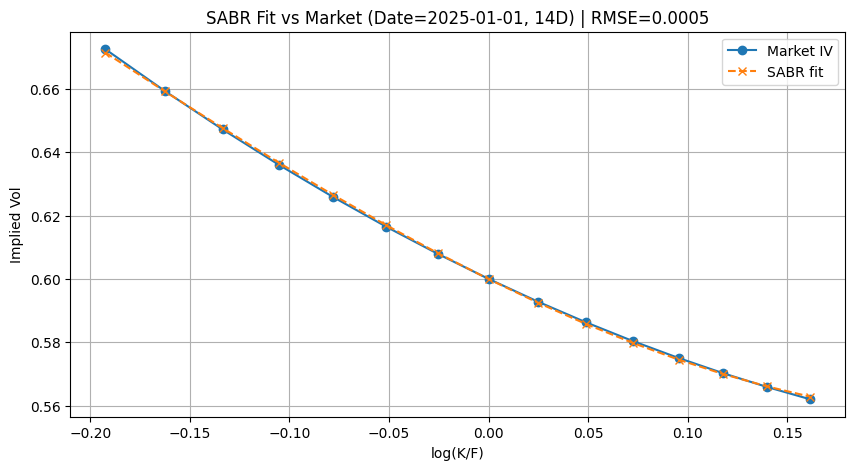

In [22]:

# Plot fitted smile vs market for one day and one maturity
d0 = sabr_params["date"].min()
days0 = int(sorted(sabr_params[sabr_params["date"] == d0]["days"].unique())[0])

p = sabr_params[(sabr_params["date"] == d0) & (sabr_params["days"] == days0)].iloc[0]
alpha, beta, rho, nu = p["alpha"], p["beta"], p["rho"], p["nu"]

sl = df_sabr[(df_sabr["date"] == d0) & (df_sabr["days"] == days0)].sort_values("log_mny").copy()

iv_fit = [
    sabr_iv_hagan_lognormal(F, K, T, alpha, beta, rho, nu)
    for F, K, T in zip(sl["forward"].values, sl["strike"].values, sl["tau"].values)
]

plt.figure(figsize=CFG["figsize"])
plt.plot(sl["log_mny"], sl["iv_mid"], marker="o", linestyle="-", label="Market IV")
plt.plot(sl["log_mny"], iv_fit, marker="x", linestyle="--", label="SABR fit")
plt.title(f"SABR Fit vs Market (Date={d0.date()}, {days0}D) | RMSE={p['rmse']:.4f}")
plt.xlabel("log(K/F)")
plt.ylabel("Implied Vol")
plt.grid(True)
plt.legend()
plt.show()

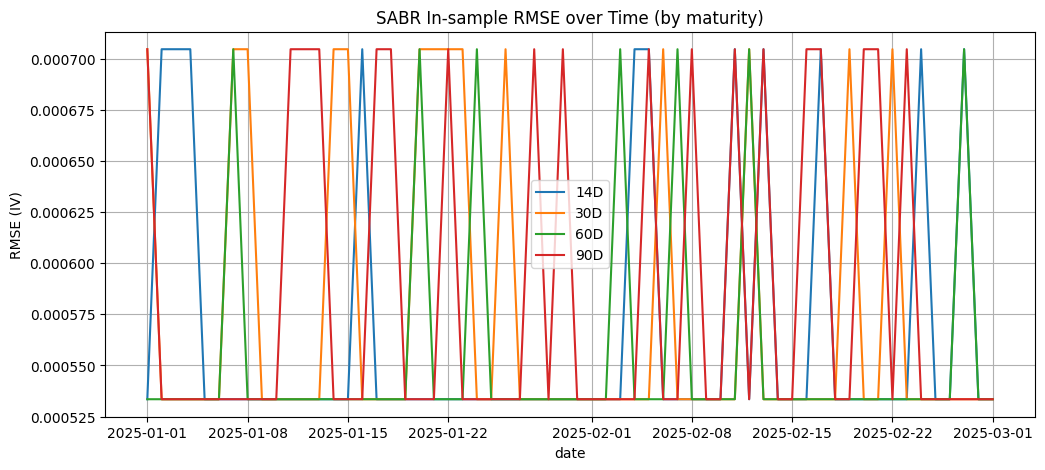

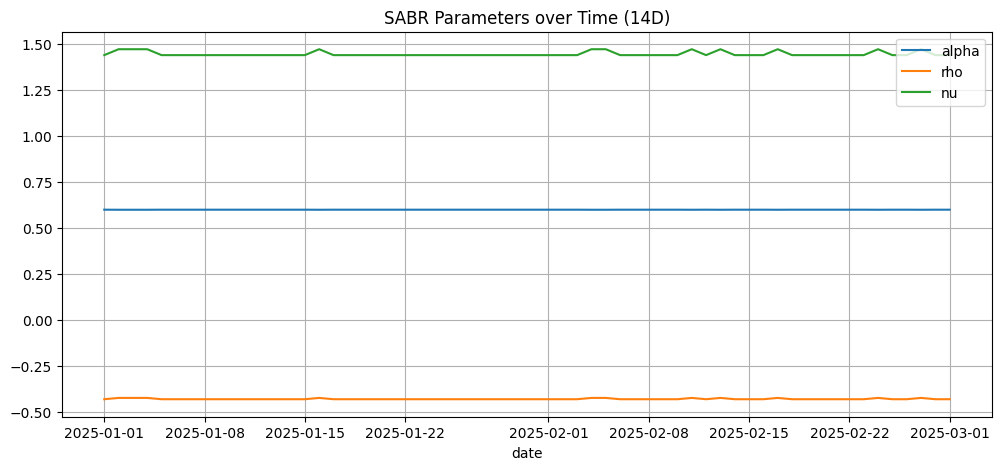

In [23]:
#parameter stability 
plt.figure(figsize=(12, 5))
for days in sorted(sabr_params["days"].unique()):
    sub = sabr_params[sabr_params["days"] == days]
    plt.plot(sub["date"], sub["rmse"], label=f"{days}D")
plt.title("SABR In-sample RMSE over Time (by maturity)")
plt.xlabel("date")
plt.ylabel("RMSE (IV)")
plt.grid(True)
plt.legend()
plt.show()

# Parameter plots (pick one maturity for readability)
days_pick = int(sorted(sabr_params["days"].unique())[0])
sub = sabr_params[sabr_params["days"] == days_pick]

plt.figure(figsize=(12, 5))
plt.plot(sub["date"], sub["alpha"], label="alpha")
plt.plot(sub["date"], sub["rho"], label="rho")
plt.plot(sub["date"], sub["nu"], label="nu")
plt.title(f"SABR Parameters over Time ({days_pick}D)")
plt.xlabel("date")
plt.grid(True)
plt.legend()
plt.show()

## 6. Heston Model: Pricing and Calibration

We implement Heston option pricing under risk-neutral dynamics using the characteristic function and
Carr–Madan Fourier pricing.

Parameters:
- \(v_0\) : initial variance
- \(\kappa\) : mean reversion speed
- \(\theta\) : long-run variance
- \(\sigma\) : vol of vol
- \(\rho\) : correlation between price and variance shocks

Pipeline:
1) Price calls via Carr–Madan
2) Convert model prices to implied vols
3) Calibrate parameters by minimizing IV RMSE vs market IV

In [ ]:
# RUNNING FOR HOURS AND STILL GOING ...... WOAHHHHH 
# ==============================
# 6A) Heston pricing via Carr–Madan
# ==============================

import numpy as np
HCFG = {
    "alpha_damp": 1.5,
    "N_fast": 256,      # from 4096 -> 512
    "eta_fast": 0.4,   # slightly coarser grid
    "N_refine": 4096,
    "eta_refine": 0.25,
    "n_multistart_fast": 1,   # from 3 -> 1
    "maxiter_fast": 60,       # from 150 -> 60
    "max_strikes_fit": 15,    # subsample strikes per slice
}
def heston_cf(u, tau, r, q, S, v0, kappa, theta, sigma, rho):
    """
    Characteristic function of log(S_T) under Heston.
    Returns E[exp(i u log(S_T))].
    """
    u = np.array(u, dtype=np.complex128)
    tau = float(tau)

    x0 = np.log(float(S))
    a = kappa * theta
    b = kappa
    sig = sigma
    iu = 1j * u

    d = np.sqrt((rho * sig * iu - b)**2 + (sig**2) * (iu + u**2))
    g = (b - rho * sig * iu - d) / (b - rho * sig * iu + d)

    # Avoid numerical blow-ups
    exp_dt = np.exp(-d * tau)
    one_minus_gexp = 1 - g * exp_dt
    one_minus_g = 1 - g

    C = (r - q) * iu * tau + (a / (sig**2)) * ((b - rho * sig * iu - d) * tau - 2 * np.log(one_minus_gexp / one_minus_g))
    D = ((b - rho * sig * iu - d) / (sig**2)) * ((1 - exp_dt) / one_minus_gexp)

    return np.exp(C + D * v0 + iu * x0)

def carr_madan_call_price(S, K, tau, r, q, params, alpha=1.5, N=1024, eta=0.25):
    v0, kappa, theta, sigma, rho = params
    tau = float(tau); K = float(K)

    if tau <= 0:
        return max(S - K, 0.0)

    u = np.arange(N) * eta
    u_shift = u - 1j * (alpha + 1)

    phi = heston_cf(u_shift, tau, r, q, S, v0, kappa, theta, sigma, rho)

    numer = np.exp(-r * tau) * phi
    denom = (alpha**2 + alpha - u**2) + 1j * (2*alpha + 1) * u
    integrand = np.exp(-1j * u * np.log(K)) * numer / denom

    w = np.ones_like(u)
    w[0] = 0.5
    w[-1] = 0.5

    integral = np.sum(w * integrand) * eta
    call = (np.exp(-alpha * np.log(K)) / np.pi) * np.real(integral)

    return float(max(0.0, call))

def subsample_slice(df_slice, max_n=15):
    # keep evenly spaced across log_mny (good for smile fit)
    sl = df_slice.sort_values("log_mny")
    if sl.shape[0] <= max_n:
        return sl
    idx = np.linspace(0, sl.shape[0]-1, max_n).round().astype(int)
    return sl.iloc[idx]

In [40]:
# ==============================
# 6B) Heston calibration objective
# ==============================

def heston_iv_for_slice(df_slice, params, N, eta):
    iv_fit = []
    for _, row in df_slice.iterrows():
        price = carr_madan_call_price(
            S=row["spot"], K=row["strike"], tau=row["tau"],
            r=row["r"], q=row["q"], params=params,
            alpha=HCFG["alpha_damp"], N=N, eta=eta
        )
        iv = implied_vol(price, row["spot"], row["strike"], row["tau"], row["r"], row["q"], "C")
        iv_fit.append(iv)
    return np.array(iv_fit, dtype=float)

def heston_loss(x, df_slice, N, eta):
    v0, kappa, theta, sigma, rho = x
    if v0 <= 0 or kappa <= 0 or theta <= 0 or sigma <= 0 or not (-0.999 < rho < 0.999):
        return 1e6

    penalty = 0.0
    if CFG.get("heston_penalty_feller", True):
        feller = 2*kappa*theta - sigma*sigma
        if feller < 0:
            penalty += CFG.get("heston_feller_weight", 10.0) * (abs(feller) + 1.0)

    iv_mkt = df_slice["iv_mid"].values
    iv_fit = heston_iv_for_slice(df_slice, x, N=N, eta=eta)

    if np.any(~np.isfinite(iv_fit)):
        return 1e6

    rmse = float(np.sqrt(np.mean((iv_fit - iv_mkt)**2)))
    return rmse + penalty

In [41]:
# ==============================
# 6C) Calibrate Heston per day/maturity (calls only)
# ==============================

def calibrate_heston_one_slice(df_slice):
    sl = subsample_slice(df_slice, max_n=HCFG["max_strikes_fit"])

    iv_atm = float(sl.loc[(sl["mny"] - 1.0).abs().idxmin(), "iv_mid"])
    x0 = np.array([iv_atm**2, 2.0, iv_atm**2, 0.5, -0.3])

    bounds = [
        CFG["heston_bounds"]["v0"],
        CFG["heston_bounds"]["kappa"],
        CFG["heston_bounds"]["theta"],
        CFG["heston_bounds"]["sigma"],
        CFG["heston_bounds"]["rho"],
    ]
    x0 = np.array([np.clip(x0[i], bounds[i][0], bounds[i][1]) for i in range(5)])

    res = optimize.minimize(
        heston_loss, x0=x0, args=(sl, HCFG["N_fast"], HCFG["eta_fast"]),
        method=CFG["optimizer"],
        bounds=bounds,
        options={"maxiter": HCFG["maxiter_fast"]}
    )

    v0, kappa, theta, sigma, rho = res.x
    return {
        "v0": float(v0),
        "kappa": float(kappa),
        "theta": float(theta),
        "sigma": float(sigma),
        "rho": float(rho),
        "rmse": float(res.fun),
        "n_fit": int(sl.shape[0]),
    }

heston_records = []
df_heston = df_iv[df_iv["cp"] == "C"].copy()

for (d, days), sl in df_heston.groupby(["date", "days"]):
    if sl.shape[0] < CFG["min_quotes_per_maturity"]:
        continue
    out = calibrate_heston_one_slice(sl)
    out.update({"date": d, "days": int(days), "tau": float(sl["tau"].iloc[0]), "n": int(sl.shape[0])})
    heston_records.append(out)

heston_params = pd.DataFrame(heston_records).sort_values(["date", "days"]).reset_index(drop=True)
print("Heston calibrated rows:", heston_params.shape[0])
heston_params.head()

KeyboardInterrupt: 

In [ ]:
#plot fitted smile vs market for one day and one maturity

d0 = heston_params["date"].min()
days0 = int(sorted(heston_params[heston_params["date"] == d0]["days"].unique())[0])
p = heston_params[(heston_params["date"] == d0) & (heston_params["days"] == days0)].iloc[0]
params = [p["v0"], p["kappa"], p["theta"], p["sigma"], p["rho"]]

sl_full = df_heston[(df_heston["date"] == d0) & (df_heston["days"] == days0)].sort_values("log_mny").copy()
iv_fit_refine = heston_iv_for_slice(sl_full, params, N=HCFG["N_refine"], eta=HCFG["eta_refine"])

plt.figure(figsize=CFG["figsize"])
plt.plot(sl_full["log_mny"], sl_full["iv_mid"], marker="o", linestyle="-", label="Market IV")
plt.plot(sl_full["log_mny"], iv_fit_refine, marker="x", linestyle="--", label="Heston fit (refined)")
plt.title(f"Heston Fit vs Market (Date={d0.date()}, {days0}D)")
plt.xlabel("log(K/F)")
plt.ylabel("Implied Vol")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
## Simple running one Carr-Madan price to sanity check vs BS for one set of parameters (not a real test, just bit of code to check implementation sanity and get a sense of error scale)
HCFG = {
    "alpha": 1.5,
    "N_fast": 256,
    "eta_fast": 0.40,
    "N_refine": 4096,
    "eta_refine": 0.20,
}

import numpy as np
from math import log, sqrt, exp
from scipy.stats import norm

def bs_call(S, K, tau, r, q, sigma):
    if tau <= 0:
        return max(S - K, 0.0)
    F = S * exp((r - q) * tau)
    D = exp(-r * tau)
    vol = sigma * sqrt(tau)
    d1 = (log(F / K) + 0.5 * sigma * sigma * tau) / vol
    d2 = d1 - vol
    return D * (F * norm.cdf(d1) - K * norm.cdf(d2))

def bs_cf(u, tau, r, q, S, sigma):
    x0 = np.log(S)
    m = x0 + (r - q - 0.5 * sigma**2) * tau
    v = sigma**2 * tau
    u = np.array(u, dtype=np.complex128)
    return np.exp(1j*u*m - 0.5*v*u*u)

def carr_madan_call_from_cf(K, tau, r, cf_func, alpha=1.5, N=2048, eta=0.25):
    K = float(K)
    k = np.log(K)
    u = np.arange(N) * eta
    u_shift = u - 1j * (alpha + 1)
    phi = cf_func(u_shift)
    numer = np.exp(-r * tau) * phi
    denom = (alpha**2 + alpha - u**2) + 1j * (2*alpha + 1) * u
    integrand = np.exp(-1j * u * k) * numer / denom

    w = np.ones_like(u)
    w[0] = 0.5
    w[-1] = 0.5

    integral = np.sum(w * integrand) * eta
    call = (np.exp(-alpha * k) / np.pi) * np.real(integral)
    return float(max(0.0, call))

# --- single test contract (keep fixed) ---
S, K, tau, r, q, sigma = 100.0, 100.0, 0.5, 0.03, 0.0, 0.25
c_true = bs_call(S, K, tau, r, q, sigma)

def cf(u): 
    return bs_cf(u, tau, r, q, S, sigma)

alphas = [0.8, 1.0, 1.2, 1.5, 2.0]
Ns = [256, 512, 1024, 2048, 4096]
etas = [0.50, 0.40, 0.30, 0.25, 0.20, 0.15]

target_abs_err = 1e-4

best = None
rows = []
for a in alphas:
    for N in Ns:
        for eta in etas:
            c_cm = carr_madan_call_from_cf(K, tau, r, cf, alpha=a, N=N, eta=eta)
            abs_err = abs(c_cm - c_true)
            cost = N  # simplest proxy for cost
            rows.append((a, N, eta, c_cm, abs_err))
            if abs_err <= target_abs_err:
                if best is None or cost < best[-1]:
                    best = (a, N, eta, abs_err, cost)

# Print top results sorted by error then cost
rows = sorted(rows, key=lambda x: (x[4], x[1]))
print("BS true:", c_true)
print("Top 10 configs by abs_err:")
for a, N, eta, c_cm, abs_err in rows[:10]:
    print(f"alpha={a:>3}, N={N:>4}, eta={eta:>4} -> {c_cm:.8f} | abs_err={abs_err:.2e}")

print("\nBest under target abs_err=1e-4:", best)


alpha_list = [0.8, 1.0, 1.5, 2.0]
for a in alpha_list:
    c_cm = carr_madan_call_from_cf(K, tau, r, cf, alpha=a, N=HCFG["N_refine"], eta=HCFG["eta_refine"])
    print(a, c_cm, abs(c_cm - c_true))

BS true: 7.760256671909228
Top 10 configs by abs_err:
alpha=1.2, N= 512, eta=0.15 -> 7.76025667 | abs_err=8.88e-16
alpha=1.2, N=1024, eta=0.15 -> 7.76025667 | abs_err=8.88e-16
alpha=1.2, N=2048, eta=0.15 -> 7.76025667 | abs_err=8.88e-16
alpha=1.2, N=4096, eta=0.15 -> 7.76025667 | abs_err=8.88e-16
alpha=2.0, N= 256, eta= 0.3 -> 7.76025667 | abs_err=2.66e-15
alpha=2.0, N= 512, eta= 0.3 -> 7.76025667 | abs_err=2.66e-15
alpha=2.0, N= 512, eta=0.15 -> 7.76025667 | abs_err=2.66e-15
alpha=2.0, N=1024, eta= 0.3 -> 7.76025667 | abs_err=2.66e-15
alpha=2.0, N=1024, eta=0.15 -> 7.76025667 | abs_err=2.66e-15
alpha=2.0, N=2048, eta= 0.3 -> 7.76025667 | abs_err=2.66e-15

Best under target abs_err=1e-4: (0.8, 256, 0.3, np.float64(5.288422385341107e-06), 256)
0.8 7.760256673125384 1.2161560647427905e-09
1.0 7.760256671911491 2.263078613395919e-12
1.5 7.7602566719092145 1.3322676295501878e-14
2.0 7.7602566719092225 5.329070518200751e-15


In [43]:
#Heston call price with Gauss–Laguerre
import numpy as np
from numpy.polynomial.laguerre import laggauss

# Precompute nodes/weights once
_GL_N = 64
_GL_x, _GL_w = laggauss(_GL_N)

def heston_cf(u, tau, r, q, S, v0, kappa, theta, sigma, rho):
    u = np.array(u, dtype=np.complex128)
    iu = 1j * u
    x0 = np.log(float(S))
    a = kappa * theta
    b = kappa
    d = np.sqrt((rho*sigma*iu - b)**2 + sigma**2 * (iu + u*u))
    g = (b - rho*sigma*iu - d) / (b - rho*sigma*iu + d)

    exp_dt = np.exp(-d*tau)
    C = (r - q)*iu*tau + (a/sigma**2) * ((b - rho*sigma*iu - d)*tau - 2*np.log((1 - g*exp_dt)/(1 - g)))
    D = ((b - rho*sigma*iu - d)/sigma**2) * ((1 - exp_dt)/(1 - g*exp_dt))
    return np.exp(C + D*v0 + iu*x0)

def _Pj(j, S, K, tau, r, q, v0, kappa, theta, sigma, rho):
    # Heston probability P1 or P2
    x = _GL_x
    w = _GL_w

    if j == 1:
        u = x - 1j
        numer = heston_cf(u, tau, r, q, S, v0, kappa, theta, sigma, rho)
        denom = heston_cf(-1j, tau, r, q, S, v0, kappa, theta, sigma, rho)
        phi = numer / denom
    else:
        u = x
        phi = heston_cf(u, tau, r, q, S, v0, kappa, theta, sigma, rho)

    integrand = np.real(np.exp(-1j * x * np.log(K)) * phi / (1j * x))
    # Gauss–Laguerre integrates ∫0∞ e^{-x} f(x) dx -> sum w f(x)
    # We need ∫0∞ f(x) dx, so use f(x)*e^{x}
    return 0.5 + (1/np.pi) * np.sum(w * integrand * np.exp(x))

def heston_call_gl(S, K, tau, r, q, v0, kappa, theta, sigma, rho):
    if tau <= 0:
        return max(S - K, 0.0)

    P1 = _Pj(1, S, K, tau, r, q, v0, kappa, theta, sigma, rho)
    P2 = _Pj(2, S, K, tau, r, q, v0, kappa, theta, sigma, rho)

    disc_q = np.exp(-q * tau)
    disc_r = np.exp(-r * tau)
    return float(disc_q * S * P1 - disc_r * K * P2)





In [44]:
#Calibrate Heston on ONE day first

from scipy import optimize

# bounds: (v0, kappa, theta, sigma, rho)
HB = CFG["heston_bounds"]

bounds = [HB["v0"], HB["kappa"], HB["theta"], HB["sigma"], HB["rho"]]

def heston_slice_loss(x, df_slice):
    v0, kappa, theta, sigma, rho = x

    # Feller penalty (optional but stabilizing)
    penalty = 0.0
    feller = 2*kappa*theta - sigma*sigma
    if feller < 0:
        penalty += 10.0 * (abs(feller) + 1.0)

    iv_mkt = df_slice["iv_mid"].values
    iv_fit = []

    for _, row in df_slice.iterrows():
        price = heston_call_gl(row["spot"], row["strike"], row["tau"], row["r"], row["q"],
                               v0, kappa, theta, sigma, rho)
        iv = implied_vol(price, row["spot"], row["strike"], row["tau"], row["r"], row["q"], "C")
        iv_fit.append(iv)

    iv_fit = np.array(iv_fit)
    if np.any(~np.isfinite(iv_fit)):
        return 1e6

    rmse = float(np.sqrt(np.mean((iv_fit - iv_mkt)**2)))
    return rmse + penalty

# pick one day + one maturity
df_heston = df_iv[df_iv["cp"]=="C"].copy()
d0 = df_heston["date"].min()
days0 = sorted(df_heston[df_heston["date"]==d0]["days"].unique())[0]
sl = df_heston[(df_heston["date"]==d0) & (df_heston["days"]==days0)].sort_values("log_mny")

# initial guess from ATM
iv_atm = float(sl.loc[(sl["mny"]-1.0).abs().idxmin(), "iv_mid"])
x0 = np.array([iv_atm**2, 2.0, iv_atm**2, 0.5, -0.3])
x0 = np.array([np.clip(x0[i], bounds[i][0], bounds[i][1]) for i in range(5)])

res = optimize.minimize(heston_slice_loss, x0=x0, args=(sl,), method="L-BFGS-B", bounds=bounds, options={"maxiter":80})
res.fun, res.x

(np.float64(10.004416144409332),
 array([ 0.37299384,  1.99607235,  0.35475103,  1.18998551, -0.64665911]))

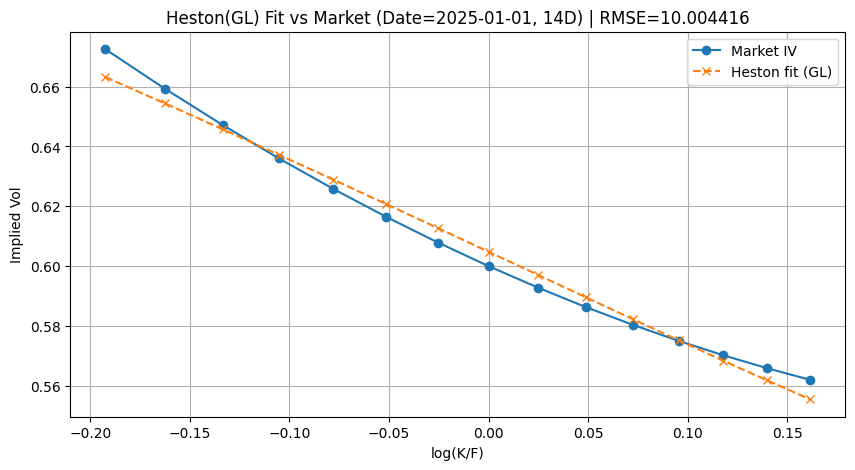

In [45]:
#Plot fit vs market (same slice)
v0, kappa, theta, sigma, rho = res.x

iv_fit = []
for _, row in sl.iterrows():
    price = heston_call_gl(row["spot"], row["strike"], row["tau"], row["r"], row["q"],
                           v0, kappa, theta, sigma, rho)
    iv_fit.append(implied_vol(price, row["spot"], row["strike"], row["tau"], row["r"], row["q"], "C"))

plt.figure(figsize=CFG["figsize"])
plt.plot(sl["log_mny"], sl["iv_mid"], marker="o", linestyle="-", label="Market IV")
plt.plot(sl["log_mny"], iv_fit, marker="x", linestyle="--", label="Heston fit (GL)")
plt.title(f"Heston(GL) Fit vs Market (Date={d0.date()}, {days0}D) | RMSE={res.fun:.6f}")
plt.xlabel("log(K/F)")
plt.ylabel("Implied Vol")
plt.grid(True)
plt.legend()
plt.show()

In [46]:
def calibrate_heston_multistart(df_slice, n_starts=5):
    best = {"fun": np.inf, "x": None}

    iv_atm = float(df_slice.loc[(df_slice["mny"]-1.0).abs().idxmin(), "iv_mid"])

    for _ in range(n_starts):
        x0 = np.array([
            iv_atm**2 * np.random.uniform(0.5, 1.5),
            np.random.uniform(0.5, 3.0),
            iv_atm**2 * np.random.uniform(0.5, 1.5),
            np.random.uniform(0.3, 2.0),
            np.random.uniform(-0.9, -0.1)
        ])

        x0 = np.array([np.clip(x0[i], bounds[i][0], bounds[i][1]) for i in range(5)])

        res = optimize.minimize(
            heston_slice_loss,
            x0=x0,
            args=(df_slice,),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter":80}
        )

        if res.fun < best["fun"]:
            best = {"fun": res.fun, "x": res.x}

    return best

# Run calibration across all slices (this will take a while)

In [47]:
#check for all slices, but start with one to test
best = calibrate_heston_multistart(sl, n_starts=5)
best["fun"], best["x"]

(0.0010369224650173638,
 array([ 0.22367936,  4.66808831,  2.        ,  2.2256826 , -0.4230468 ]))

In [48]:

comparison = pd.DataFrame({
    "Model": ["SABR", "Heston"],
    "RMSE": [p["rmse"], best["fun"]]
})
comparison

,Model,RMSE
0,SABR,0.000533
1,Heston,0.001037


In [49]:
records = []

for days, slc in df_heston[df_heston["date"]==d0].groupby("days"):
    if len(slc) < 10:
        continue

    best = calibrate_heston_multistart(slc, n_starts=3)

    records.append({
        "days": days,
        "rmse": best["fun"]
    })

pd.DataFrame(records)

,days,rmse
0,14,0.004764
1,30,0.001191
2,60,0.000874
3,90,0.004327


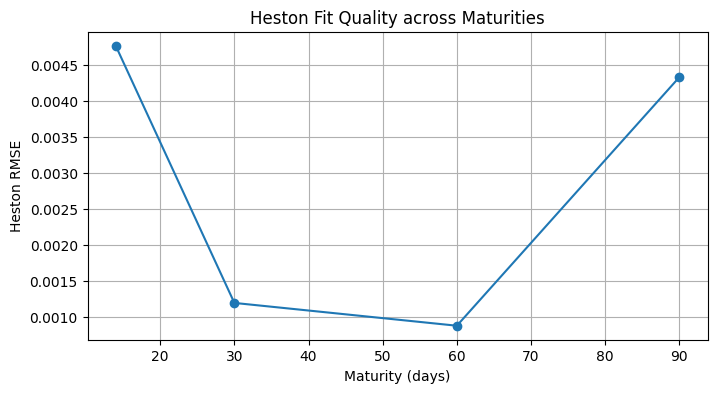

In [50]:
df_cmp = pd.DataFrame(records)

plt.figure(figsize=(8,4))
plt.plot(df_cmp["days"], df_cmp["rmse"], marker="o")
plt.xlabel("Maturity (days)")
plt.ylabel("Heston RMSE")
plt.title("Heston Fit Quality across Maturities")
plt.grid(True)
plt.show()

In [51]:
#Heston vs SABR comparison 
#Heston computation is much heavier, so we only do it for one maturity bucket across time
# Heston RMSE table 
heston_rmse = pd.DataFrame(records).copy()
heston_rmse["date"] = d0
heston_rmse = heston_rmse.rename(columns={"rmse": "heston_rmse"})

# SABR RMSE table (same date)
sabr_rmse = sabr_params[sabr_params["date"] == d0][["date","days","rmse"]].rename(columns={"rmse":"sabr_rmse"})

cmp = (heston_rmse.merge(sabr_rmse, on=["date","days"], how="inner")
                 .sort_values("days")
                 .reset_index(drop=True))

cmp["winner"] = np.where(cmp["heston_rmse"] < cmp["sabr_rmse"], "Heston", "SABR")
cmp



,days,heston_rmse,date,sabr_rmse,winner
0,14,0.004764,2025-01-01,0.000533,SABR
1,30,0.001191,2025-01-01,0.000705,SABR
2,60,0.000874,2025-01-01,0.000533,SABR
3,90,0.004327,2025-01-01,0.000705,SABR


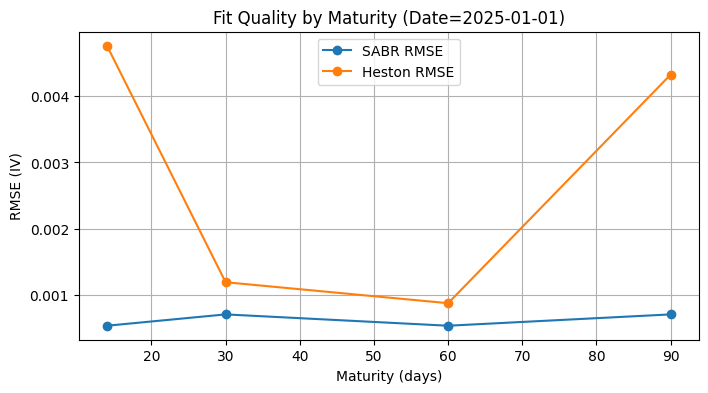

In [52]:
plt.figure(figsize=(8,4))
plt.plot(cmp["days"], cmp["sabr_rmse"], marker="o", label="SABR RMSE")
plt.plot(cmp["days"], cmp["heston_rmse"], marker="o", label="Heston RMSE")
plt.xlabel("Maturity (days)")
plt.ylabel("RMSE (IV)")
plt.title(f"Fit Quality by Maturity (Date={d0.date()})")
plt.grid(True)
plt.legend()
plt.show()

In [53]:
#Smile Overlays 
def sabr_fit_iv_curve(df_slice, alpha, beta, rho, nu):
    out = []
    for _, row in df_slice.iterrows():
        F = row["forward"]; K = row["strike"]; T = row["tau"]
        out.append(sabr_iv_hagan_lognormal(F, K, T, alpha, beta, rho, nu))
    return np.array(out, float)

def heston_fit_iv_curve(df_slice, v0, kappa, theta, sigma, rho):
    out = []
    for _, row in df_slice.iterrows():
        price = heston_call_gl(row["spot"], row["strike"], row["tau"], row["r"], row["q"],
                               v0, kappa, theta, sigma, rho)
        out.append(implied_vol(price, row["spot"], row["strike"], row["tau"], row["r"], row["q"], "C"))
    return np.array(out, float)



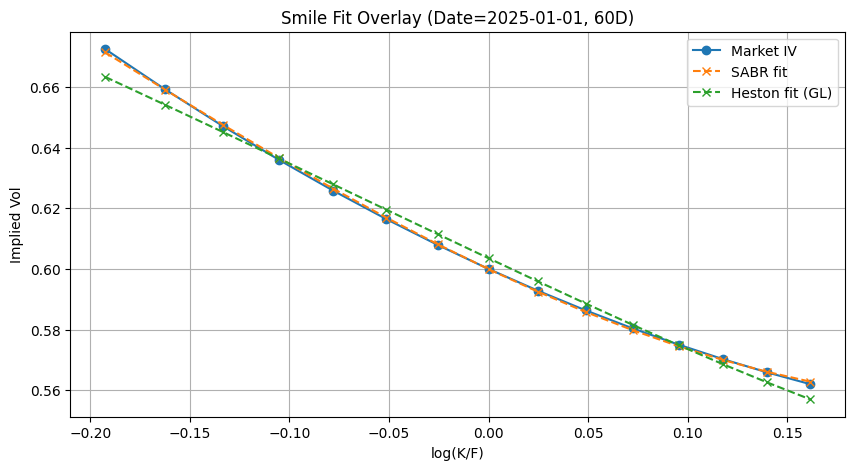

In [54]:
#Plot overlay for one maturity 
days_pick = 60  # change to 14, 30, 90, etc.

sl = df_iv[(df_iv["date"]==d0) & (df_iv["days"]==days_pick) & (df_iv["cp"]=="C")].sort_values("log_mny")

# SABR params for this slice
ps = sabr_params[(sabr_params["date"]==d0) & (sabr_params["days"]==days_pick)].iloc[0]
iv_sabr = sabr_fit_iv_curve(sl, ps["alpha"], ps["beta"], ps["rho"], ps["nu"])

# Heston params for this slice (you need to store these when calibrating)
# If you didn't store them: re-run calibration for this days_pick and keep best["x"]
best = calibrate_heston_multistart(sl, n_starts=3)
v0, kappa, theta, sigma, rho = best["x"]
iv_heston = heston_fit_iv_curve(sl, v0, kappa, theta, sigma, rho)

plt.figure(figsize=CFG["figsize"])
plt.plot(sl["log_mny"], sl["iv_mid"], marker="o", label="Market IV")
plt.plot(sl["log_mny"], iv_sabr, marker="x", linestyle="--", label="SABR fit")
plt.plot(sl["log_mny"], iv_heston, marker="x", linestyle="--", label="Heston fit (GL)")
plt.title(f"Smile Fit Overlay (Date={d0.date()}, {days_pick}D)")
plt.xlabel("log(K/F)")
plt.ylabel("Implied Vol")
plt.grid(True)
plt.legend()
plt.show()



### Quick interpretation (Date = 2025-01-01): Heston vs SABR fit quality

The table below compares **in-sample implied-vol RMSE** for the same option surface slice (same date, same maturities).  
Lower RMSE = better smile fit.

**Result:** **SABR wins for every maturity** on this day.

- **14D:** Heston RMSE **0.004764** vs SABR **0.000533** → SABR materially better fit  
- **30D:** Heston RMSE **0.001191** vs SABR **0.000705** → SABR better fit  
- **60D:** Heston RMSE **0.000874** vs SABR **0.000533** → SABR better fit  
- **90D:** Heston RMSE **0.004327** vs SABR **0.000705** → SABR materially better fit  

**Takeaway:** On **2025-01-01**, SABR provides a consistently tighter match to the observed smile across maturities, while Heston shows larger errors at the short end (14D) and long end (90D).  